## Time series with `pytimetk` and `statsforecast`

We use ARIMA and ETS models for forecasting bicycle sales data. The examples illustrate multiple time series modeling. This notebook adapted from Matt Dancho/Business Science University webinar on time series modeling, July 2024.

#### The data: 
This is real sales data for Cannondale, a leading U.S. bicycle company. The data has been processed from multiple tables using some SQL and data wrangling, so you dont have to worry about any of that. You can download `bikeshop_data.csv` from Brightspace.

#### Libraries:
Install the following libraries. Only need to do this once on a personal machine. 

In [ ]:
!pip install pytimetk
!pip install statsforecast



You *may* need to install these.

In [ ]:
!pip install nbformat>=4.2.0p
!pip install ipywidgets

In [1]:
import pandas as pd

import pytimetk as tk

from statsforecast.models import AutoARIMA, AutoETS  # Changed ETS to AutoETS
from statsforecast import StatsForecast

We see that we have many rows for any given date, corresponding to different stores, categories and subcategories, etc. 

In [2]:
df = pd.read_csv('../../data/bikeshop_data.csv')
df.shape

(15644, 13)

A last bit of wrangling is to put the dates into datetime format.

In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])
df.head()

,order_id,order_line,order_date,model,quantity,price,total_price,bikeshop_name,category_1,category_2,frame_material,city,state
0,1,1,2011-01-07,Jekyll Carbon 2,1,6070,6070,Ithaca Mountain Climbers,Mountain,Over Mountain,Carbon,Ithaca,NY
1,1,2,2011-01-07,Trigger Carbon 2,1,5970,5970,Ithaca Mountain Climbers,Mountain,Over Mountain,Carbon,Ithaca,NY
2,2,1,2011-01-10,Beast of the East 1,1,2770,2770,Kansas City 29ers,Mountain,Trail,Aluminum,Kansas City,KS
3,2,2,2011-01-10,Trigger Carbon 2,1,5970,5970,Kansas City 29ers,Mountain,Over Mountain,Carbon,Kansas City,KS
4,3,1,2011-01-10,Supersix Evo Hi-Mod Team,1,10660,10660,Louisville Race Equipment,Road,Elite Road,Carbon,Louisville,KY


An example of an aggregate summary. We will use this to model a time series for each sub category of bicycle. 

- `groupby` is a pandas method. Analogous to `group_by` in R. It returns another data frame. 
- The backslash just allows splitting code by line. Not necessary but might make for readability. It's a style thing.
- `summarize_by_time` is a `pytimetk` method. The arguments are pretty self evident, except for 
- `MS` is for "Month Start" and indicates monthly summarizing.


In [4]:
sales_by_month_cat_2 = df \
.groupby('category_2') \
    .summarize_by_time(
        date_column='order_date',
        value_column='total_price',
        freq = 'MS',
        agg_func = 'sum'
    )

sales_by_month_cat_2

,category_2,order_date,total_price
0,Cross Country Race,2011-01-01,143660
1,Cross Country Race,2011-02-01,324400
2,Cross Country Race,2011-03-01,142000
3,Cross Country Race,2011-04-01,498580
4,Cross Country Race,2011-05-01,220310
...,...,...,...
534,Triathalon,2015-08-01,39200
535,Triathalon,2015-09-01,75600
536,Triathalon,2015-10-01,58600
537,Triathalon,2015-11-01,70050


`plot_timeseries` is again a pytimetk method. You can used different plotting engines on the backend. Use the plotly engine for interactive plot. You can mouse over.

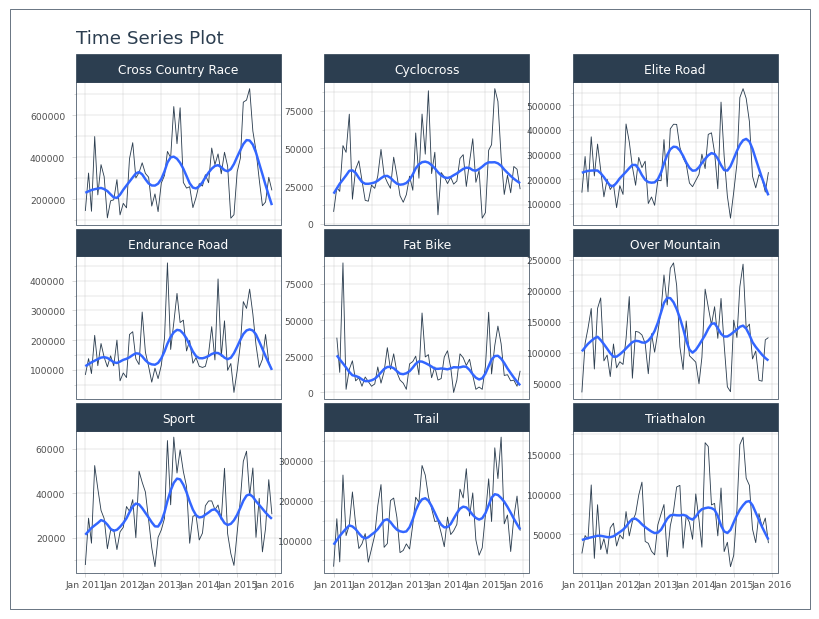

In [19]:
# * Interactive Plotting with plotly engine
fig = sales_by_month_cat_2 \
    .groupby('category_2') \
    .plot_timeseries(
        date_column = 'order_date',
        value_column = 'total_price',
        facet_ncol = 3,
        #engine = "plotly"
        engine = "matplotlib"  # Alternative: use this for static plots to avoid nbformat issues
    )

fig

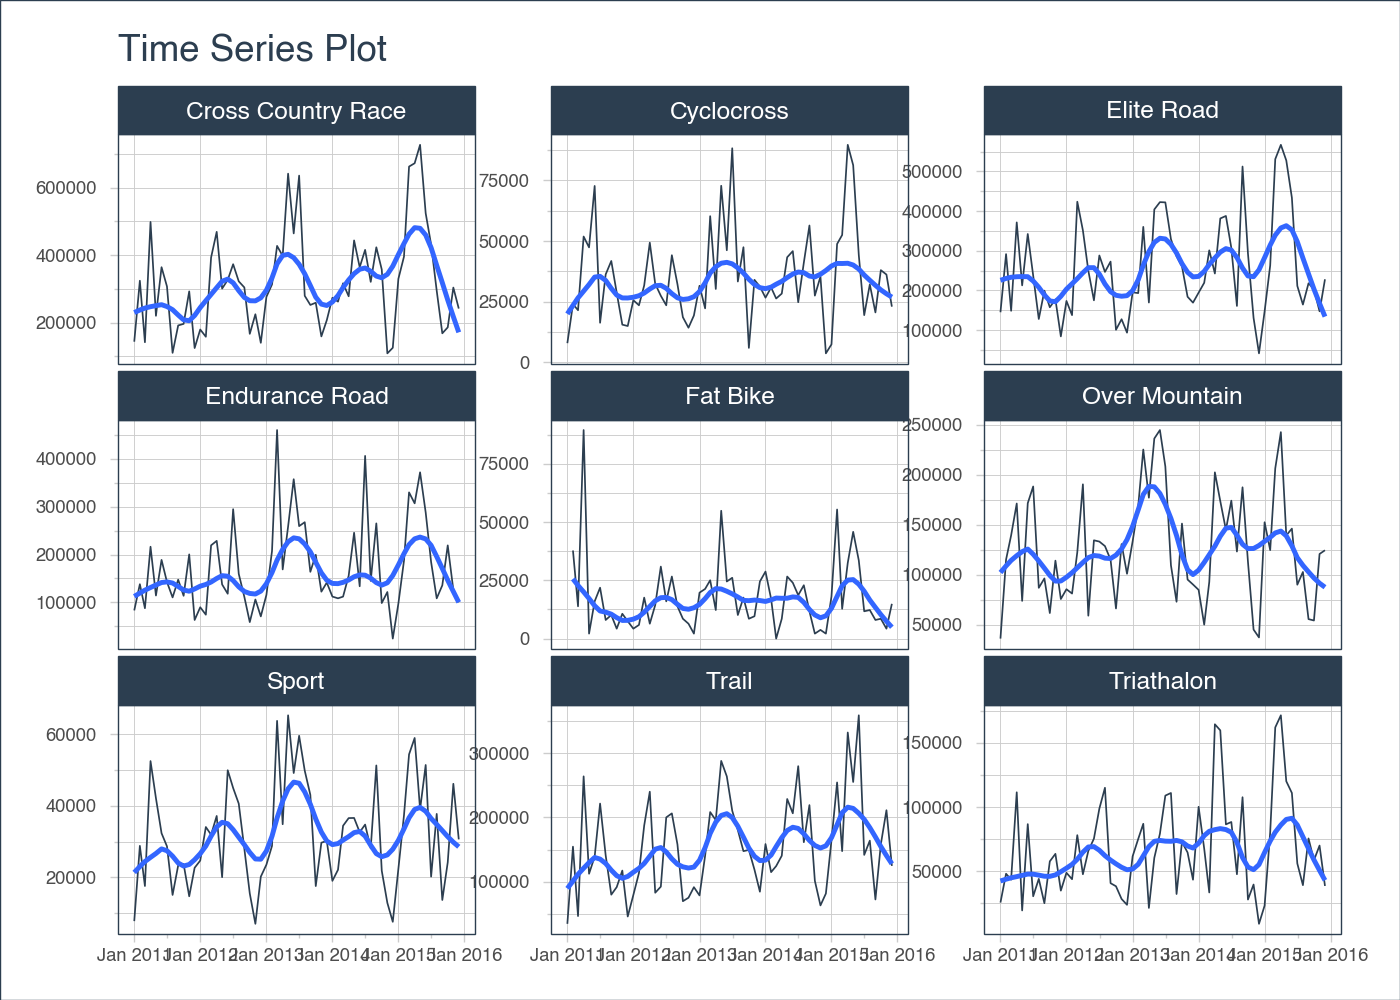

In [6]:

sales_by_month_cat_2 \
    .groupby('category_2') \
    .plot_timeseries(
        date_column = 'order_date',
        value_column = 'total_price',
        facet_ncol = 3,
        engine = "plotnine"
    )

#### ARIMA model

Here we use the `statsforecast` library. The Nixtla documentation has an excellent summary on ARIMA modeling under the "Model References" section. The three main model parameters- the AR, differencing, and MA orders- were also mentioned in the `chicago_rnn` notebook.  Chapter 9 in fpp3 also covers ARIMA. 

Now what is AutoARIMA? It is a model that automatically selects the optimal model parameters! Check the Nixtla docs for details. 

Note that below we are fitting a time series for every subcategory of bicycle.


In [7]:
# * Step 1: Specify Time Series Forecasting Models

models = [
    AutoARIMA(season_length=12), # Automatic ARIMA with Seasonal
    AutoETS(season_length=12), # Changed ETS to AutoETS - Automatic Exponential Smoothing with Error-Trend-Seasonal
]

models

[AutoARIMA, AutoETS]

In [8]:

# * Step 2: Create the StatsForecast Object Specification

sf = StatsForecast(models=models, freq='MS', n_jobs=1)


# * Step 3: Train the StatsForecast Object

sf.fit(
    df = sales_by_month_cat_2,
    id_col = 'category_2',
    time_col='order_date',
    target_col='total_price',
)


StatsForecast(models=[AutoARIMA,AutoETS])

Here are a year's worth of monthly forecasts

In [9]:
# * Step 5: Forecast

df_forecast = sf.predict(h=12, level=[80,95])
df_forecast




,category_2,order_date,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95
0,Cross Country Race,2016-01-01,315049.375000,79380.335938,160953.671875,469145.062500,550718.437500,279171.750000,83916.679688,151501.328125,406842.187500,474426.843750
1,Cross Country Race,2016-02-01,339957.843750,74793.937500,166576.484375,513339.218750,605121.750000,340637.468750,143274.906250,211589.031250,469685.875000,538000.000000
2,Cross Country Race,2016-03-01,428510.187500,156038.484375,250350.515625,606669.875000,700981.875000,477621.125000,276172.937500,345901.218750,609341.000000,679069.312500
3,Cross Country Race,2016-04-01,432655.187500,158272.562500,253246.031250,612064.312500,707037.750000,554114.375000,347285.718750,418876.406250,689352.375000,760943.000000
4,Cross Country Race,2016-05-01,450885.500000,175996.906250,271145.500000,630625.500000,725774.125000,544694.125000,332787.906250,406136.093750,683252.125000,756600.312500
...,...,...,...,...,...,...,...,...,...,...,...,...
103,Triathalon,2016-08-01,66764.367188,-9265.591797,17051.048828,116477.679688,142794.328125,90612.414062,19350.363281,44016.664062,137208.171875,161874.468750
104,Triathalon,2016-09-01,66769.609375,-9260.349609,17056.291016,116482.929688,142799.562500,61630.886719,-9915.704102,14849.085938,108412.687500,133177.484375
105,Triathalon,2016-10-01,66771.507812,-9258.454102,17058.187500,116484.820312,142801.468750,58458.371094,-13343.795898,11509.458008,105407.289062,130260.539062
106,Triathalon,2016-11-01,66772.187500,-9257.768555,17058.873047,116485.507812,142802.156250,58925.734375,-13135.732422,11807.274414,106044.195312,130987.203125


and plots, with prediction intervals

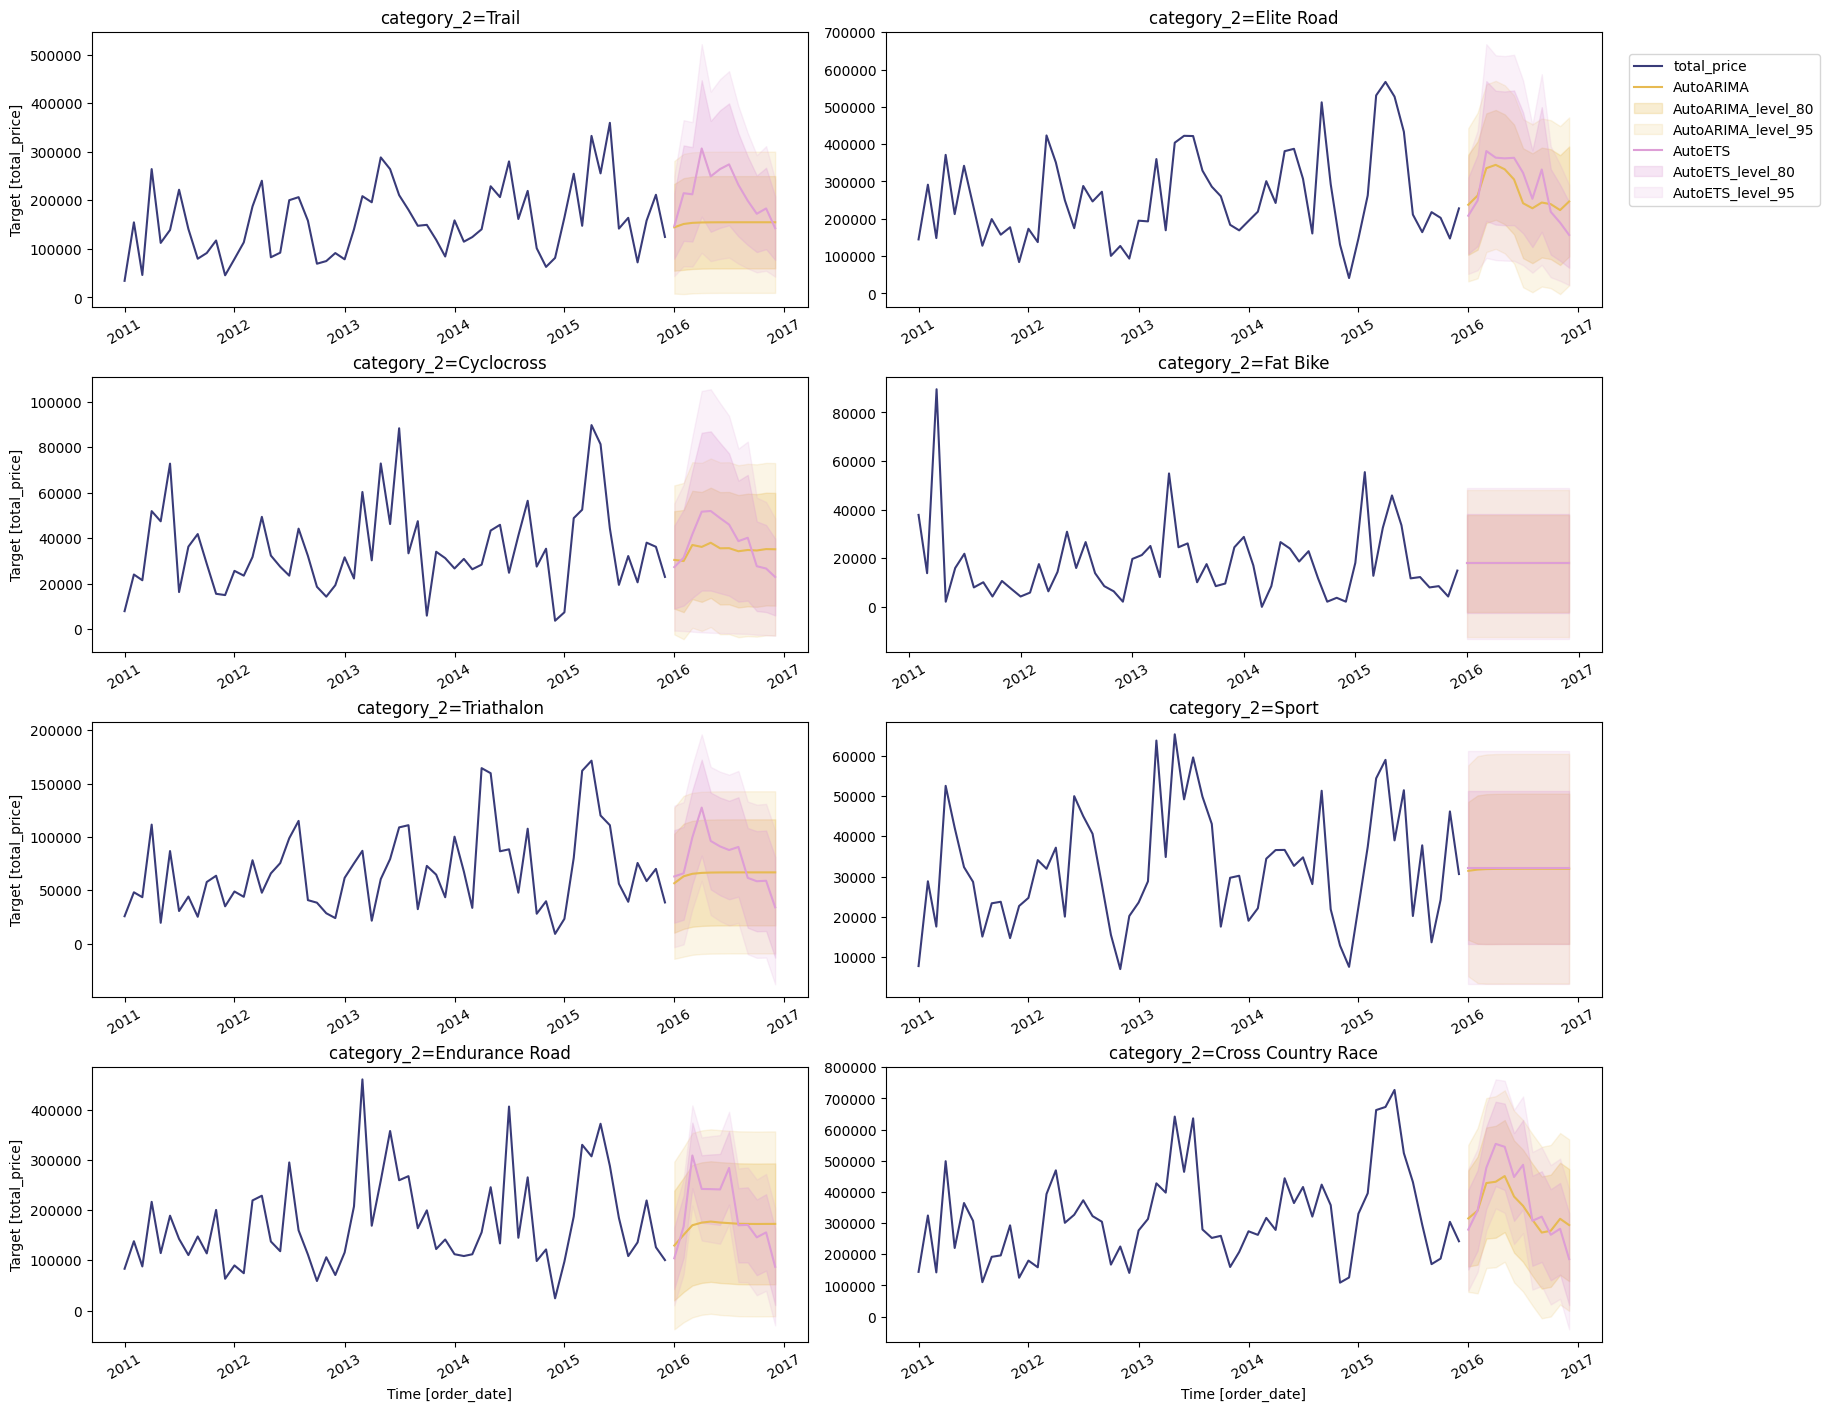

In [13]:
# * Step 6: Visualize

fig = sf.plot(
    df           = sales_by_month_cat_2,
    forecasts_df = df_forecast,
    level        = [80,95],
    id_col       = 'category_2',
    time_col     ='order_date',
    target_col   ='total_price',
    #engine       = 'plotly'
    engine     = 'matplotlib'  # Alternative: use this for static plots to avoid nbformat issues
)

fig
